## Week 7 Video Notebook: Tree Ensembles

In this notebook, we'll learn how to build, tune, interpret, and evaluate Random Forests and Boosting Trees using Scikit-learn:

* Train and evaluate a **Random Forest Regressor** using the California Housing dataset.
    * Use **manual validation curves with 5-fold cross-validation** to understand the behavior of important Random Forest hyperparameters and identify promising ranges.
    * Use **RandomizedSearchCV with repeated cross-validation** to evaluate combinations of Random Forest hyperparameters efficiently and account for interactions among them.
* Train and evaluate a **HistGradientBoostingClassifier** using the Wisconsin Breast Cancer dataset.
    * Introduce **early stopping** as a way to determine automatically when additional boosting iterations no longer improve validation performance.
    * Use manual sweeps to study important boosting hyperparameters while early stopping controls the number of boosting iterations.
    * Use **GridSearchCV with repeated stratified cross-validation** to search a restricted region of promising boosting hyperparameters and identify the best-performing combination.
* Select models using development-set evidence only, then evaluate each final model once on an **untouched test set**.
* Measure **impurity-based** and **permutation** feature importance to identify influential predictors.


### Imports

In [1]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.datasets import (
    fetch_california_housing,
    load_breast_cancer
)

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingClassifier
)

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.model_selection import (
    cross_val_predict,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    train_test_split
)

from sklearn.pipeline import make_pipeline


# --------------------------------------------------
# Global settings
# --------------------------------------------------

random_seed = 42


# --------------------------------------------------
# Utility function
# --------------------------------------------------

def print_elapsed_time(start):

    elapsed = time.perf_counter() - start

    hours, remainder = divmod(
        int(elapsed),
        3600
    )

    minutes, seconds = divmod(
        remainder,
        60
    )

    print(
        f"Elapsed time = "
        f"{hours:02d}:{minutes:02d}:{seconds:02d}"
    )


# --------------------------------------------------
# Optional warning suppression
# --------------------------------------------------

# To suppress occasional joblib worker warnings:
#
# import warnings
# warnings.filterwarnings(
#     "ignore",
#     category=UserWarning
# )

## Random Forest Regression

Our strategy here is a bit different than in Week 6. 
- We first sweep several important hyperparameters individually to understand their behavior and identify promising ranges.
- We then use randomized search with repeated cross-validation to evaluate combinations of hyperparameters and account for interactions among them.

### Load and split the data

In [2]:
# Load the California Housing Dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [4]:
# Split dataset into training and testing sets
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.1, random_state=random_seed)

### Random Forest Regressor (Default)


In [5]:
# --------------------------------------------------
# Baseline Random Forest Regressor
# --------------------------------------------------

model_RFR_default = RandomForestRegressor(

    # Number of trees
    n_estimators=100,                 # Default

    # Splitting criterion
    criterion="squared_error",        # Default

    # Tree size
    max_depth=None,                   # Defaults
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,

    # Number of features considered at each split
    max_features=1.0,                 # Default: all features

    # Bootstrap sampling of observations
    bootstrap=True,                   # Default
    max_samples=None,                 # Use full-size bootstrap samples

    # Cost-complexity pruning
    ccp_alpha=0.0,                    # Default

    # Reproducibility
    random_state=random_seed
)


# --------------------------------------------------
# Five-Fold Cross-Validation
# --------------------------------------------------

regression_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)

neg_mae_scores = cross_val_score(
    model_RFR_default,
    X_dev,
    y_dev,
    scoring="neg_mean_absolute_error",
    cv=regression_cv,
    n_jobs=-1
)

cv_mae_scores = -neg_mae_scores

mean_cv_mae = cv_mae_scores.mean()
std_cv_mae = cv_mae_scores.std()


# --------------------------------------------------
# Report Results
# --------------------------------------------------

print("Baseline Random Forest Regression")
print("---------------------------------")
print(f"5-Fold MAEs : {np.round(cv_mae_scores, 4)}")
print(f"Mean CV MAE : {mean_cv_mae:.4f}")
print(f"Std CV MAE  : {std_cv_mae:.4f}")

Baseline Random Forest Regression
---------------------------------
5-Fold MAEs : [0.3268 0.343  0.3213 0.3291 0.3321]
Mean CV MAE : 0.3305
Std CV MAE  : 0.0072


### Hyperparameter Tuning Wrapper Function


In [6]:
def sweep_random_forest_regressor(param, parameter_list):

    training_maes = []
    cv_maes = []

    for value in tqdm(parameter_list):

        model_params = {
            "n_estimators": 100,
            "criterion": "squared_error",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "max_leaf_nodes": None,
            "max_features": 1.0,
            "bootstrap": True,
            "max_samples": None,
            "ccp_alpha": 0.0,
            "random_state": random_seed,
            "n_jobs": -1,
        }

        # Change only the parameter being studied
        model_params[param] = value

        model = RandomForestRegressor(**model_params)

        # Training performance
        model.fit(X_dev, y_dev)

        y_dev_pred = model.predict(X_dev)

        training_mae = mean_absolute_error(
            y_dev,
            y_dev_pred
        )

        training_maes.append(training_mae)

        # Cross-validation performance
        neg_mae_scores = cross_val_score(
            model,
            X_dev,
            y_dev,
            scoring="neg_mean_absolute_error",
            cv=regression_cv,
            n_jobs=-1
        )

        mean_cv_mae = -neg_mae_scores.mean()
        cv_maes.append(mean_cv_mae)

    # Identify best value
    best_index = np.argmin(cv_maes)
    best_value = parameter_list[best_index]
    best_cv_mae = cv_maes[best_index]

    # Plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        parameter_list,
        training_maes,
        marker=".",
        label="Training MAE"
    )

    plt.plot(
        parameter_list,
        cv_maes,
        marker=".",
        label="CV MAE"
    )

    plt.scatter(
        best_value,
        best_cv_mae,
        marker="x",
        s=80,
        label=(
            f"Best CV MAE = {best_cv_mae:.4f}\n"
            f"at {param} = {best_value}"
        )
    )

    plt.title(
        f"Random Forest Regressor: MAE vs {param}"
    )
    plt.xlabel(param)
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Minimum CV MAE = {best_cv_mae:.4f}")
    print(f"Best {param} = {best_value}")

100%|███████████████████████████████████████████| 20/20 [01:12<00:00,  3.62s/it]


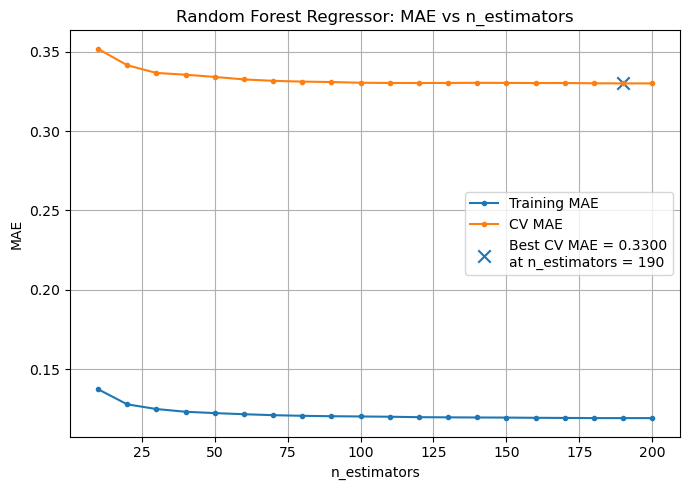

Minimum CV MAE = 0.3300
Best n_estimators = 190


100%|███████████████████████████████████████████| 29/29 [01:15<00:00,  2.60s/it]


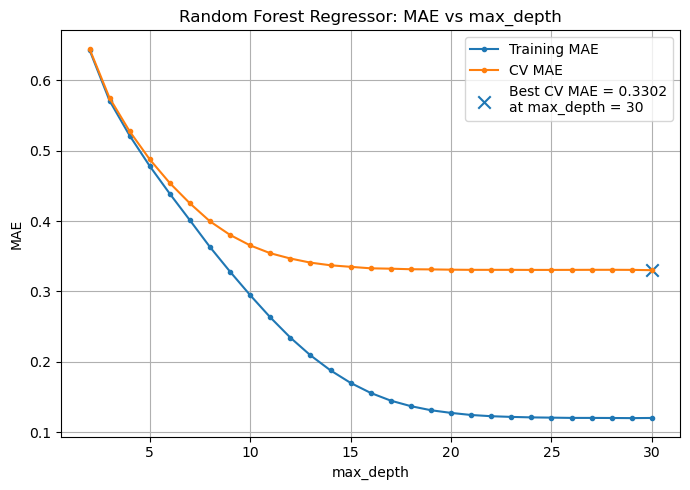

Minimum CV MAE = 0.3302
Best max_depth = 30


100%|█████████████████████████████████████████████| 8/8 [00:16<00:00,  2.09s/it]


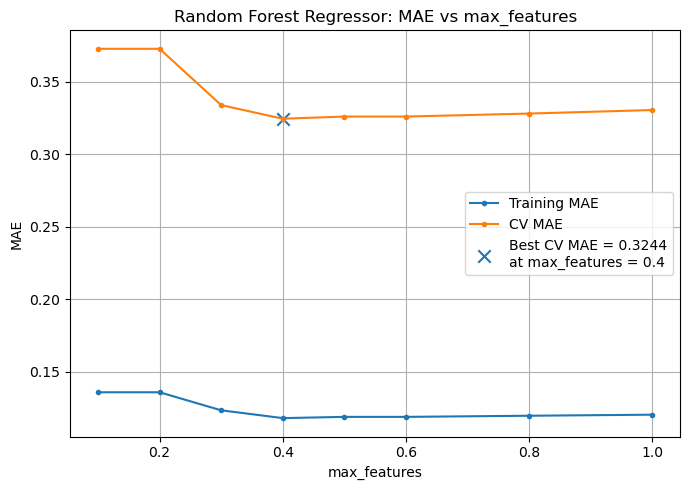

Minimum CV MAE = 0.3244
Best max_features = 0.4


100%|█████████████████████████████████████████████| 8/8 [00:19<00:00,  2.46s/it]


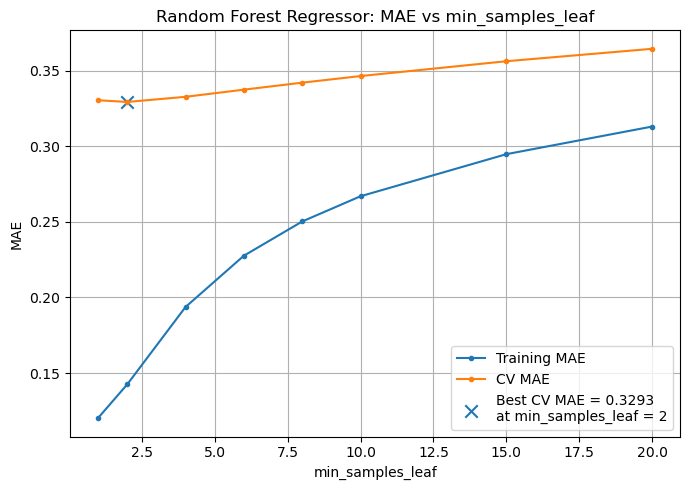

Minimum CV MAE = 0.3293
Best min_samples_leaf = 2


100%|█████████████████████████████████████████████| 6/6 [00:15<00:00,  2.58s/it]


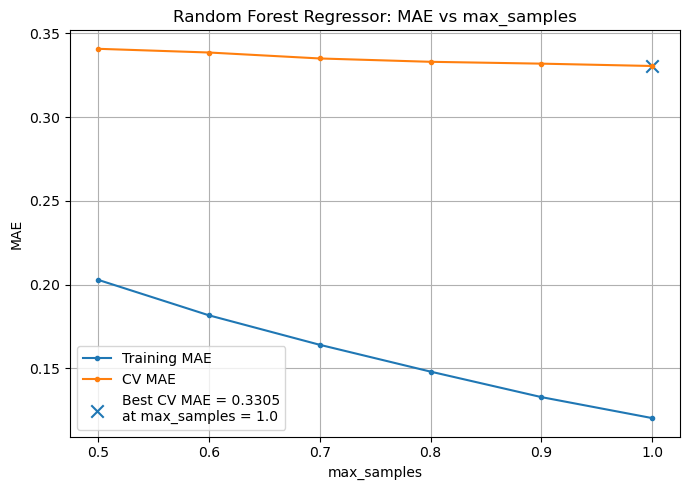

Minimum CV MAE = 0.3305
Best max_samples = 1.0


In [7]:
# Number of trees
sweep_random_forest_regressor(
    "n_estimators",
    range(10, 210, 10)
)

# Maximum tree depth
sweep_random_forest_regressor(
    "max_depth",
    range(2, 31)
)

# Fraction of features considered at each split
sweep_random_forest_regressor(
    "max_features",
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
)

# Minimum samples required in each leaf
sweep_random_forest_regressor(
    "min_samples_leaf",
    [1, 2, 4, 6, 8, 10, 15, 20]
)

# Fraction of training observations used in each bootstrap sample
sweep_random_forest_regressor(
    "max_samples",
    [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

#### Comment:

The individual sweeps reveal several useful patterns. 
- Performance improves rapidly as `n_estimators` increases, but then reaches a broad plateau, so there is little reason to chase the numerically best value at the far end of the range.
- Similarly, `max_depth` improves performance up to roughly the mid-teens and then changes very little. `max_features` shows a clearer optimum in the neighborhood of 0.4–0.6, while larger values of `min_samples_leaf` steadily reduce performance.
- Finally, `max_samples` performs best near 1.0, so we will fix it at that value rather than include it in the joint search.

> These one-parameter sweeps help us identify promising regions, but they do not show how hyperparameters interact. We therefore use `RandomizedSearchCV` over the restricted ranges suggested by the sweeps, together with repeated K-fold cross-validation, to evaluate combinations of hyperparameter values more robustly.

#### Randomized Search on Restricted Ranges with Repeated KFold Cross-Validation

In [8]:
# --------------------------------------------------
# Randomized Search over Promising Hyperparameter Regions
# --------------------------------------------------

start = time.perf_counter()


# --------------------------------------------------
# Modeling Pipeline
# --------------------------------------------------

# No preprocessing is required for this dataset,
# but we use a pipeline to maintain a consistent
# modeling workflow.
rf_pipeline = make_pipeline(
    RandomForestRegressor(
        criterion="squared_error",
        bootstrap=True,
        max_samples=1.0,
        random_state=random_seed,
        n_jobs=-1
    )
)


# --------------------------------------------------
# Restricted Parameter Space
# --------------------------------------------------

# The manual sweeps identified promising regions
# for each hyperparameter. RandomizedSearchCV now
# evaluates combinations within those regions.

param_distributions = {

    # Performance largely plateaued after about 75 trees
    "randomforestregressor__n_estimators": [
        75, 100, 125, 150
    ],

    # Performance plateaued for depths above about 15
    "randomforestregressor__max_depth": [
        15, 20, 25, 30, None
    ],

    # Strongest region from the individual sweep
    "randomforestregressor__max_features": [
        0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7
    ],

    # Larger values became progressively worse
    "randomforestregressor__min_samples_leaf": [
        1, 2, 3, 4, 5
    ]
}


# --------------------------------------------------
# Repeated Cross-Validation
# --------------------------------------------------

repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_seed
)


# --------------------------------------------------
# Randomized Search
# --------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    random_state=random_seed,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(
    X_dev,
    y_dev
)


# --------------------------------------------------
# Best Result
# --------------------------------------------------

print("Random Forest Randomized Search")
print("-------------------------------")

print(
    f"Best CV MAE     : "
    f"{-random_search.best_score_:.4f}"
)

print("Best Parameters :")

for param, value in random_search.best_params_.items():
    clean_name = param.replace(
        "randomforestregressor__",
        ""
    )
    print(f"  {clean_name}: {value}")


# --------------------------------------------------
# Top 20 Models
# --------------------------------------------------

results = pd.DataFrame(
    random_search.cv_results_
)

results["CV MAE"] = -results["mean_test_score"]
results["Training MAE"] = -results["mean_train_score"]

results = (
    results
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

top_results = results[
    [
        "rank_test_score",
        "CV MAE",
        "std_test_score",
        "Training MAE",
        "param_randomforestregressor__n_estimators",
        "param_randomforestregressor__max_depth",
        "param_randomforestregressor__max_features",
        "param_randomforestregressor__min_samples_leaf"
    ]
].copy()

top_results = top_results.rename(
    columns={
        "rank_test_score": "Rank",
        "std_test_score": "CV Std",
        "param_randomforestregressor__n_estimators":
            "n_estimators",
        "param_randomforestregressor__max_depth":
            "max_depth",
        "param_randomforestregressor__max_features":
            "max_features",
        "param_randomforestregressor__min_samples_leaf":
            "min_samples_leaf"
    }
)

display(
    top_results
    .head(20)
    .round(4)
)

print_elapsed_time(start)

/opt/homebrew/Caskroom/miniforge/base/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest Randomized Search
-------------------------------
Best CV MAE     : 0.3244
Best Parameters :
  n_estimators: 75
  min_samples_leaf: 1
  max_features: 0.4
  max_depth: None


,Rank,CV MAE,CV Std,Training MAE,n_estimators,max_depth,max_features,min_samples_leaf
0,1,0.3244,0.0050,0.1216,75,None,0.40,1
1,2,0.3245,0.0056,0.1522,150,None,0.55,2
2,3,0.3245,0.0055,0.1204,150,None,0.55,1
3,4,0.3254,0.0056,0.1532,100,25,0.60,2
4,5,0.3254,0.0058,0.1567,100,20,0.60,2
5,6,0.3258,0.0056,0.1585,100,25,0.40,2
6,7,0.3261,0.0054,0.1227,75,25,0.50,1
7,8,0.3270,0.0055,0.1862,150,20,0.60,3
8,9,0.3273,0.0052,0.1538,100,20,0.65,2
9,10,0.3275,0.0053,0.1852,100,None,0.55,3


Elapsed time = 00:04:01


#### Comment:

The randomized search confirms the general patterns seen in the individual parameter sweeps. 
- The best combination achieved a mean cross-validation MAE of about 0.325, but many nearby combinations performed almost as well.
- The differences among the top models are small relative to the variation across cross-validation folds, indicating a broad region of similarly strong performance rather than one uniquely optimal set of hyperparameters.

The top-ranked models also reveal useful trends. 
- Most use relatively deep trees, `max_features` around 0.5–0.6, and small values of `min_samples_leaf`.
- The number of trees varies among the strongest models, reinforcing the earlier observation that performance has largely plateaued once the forest contains enough trees.

> Unlike the individual parameter sweeps, `RandomizedSearchCV` evaluates combinations of hyperparameters and therefore allows interactions among them to influence model selection. Because the search uses repeated K-fold cross-validation, it also provides a more stable basis for selecting the final model.

### Final Test Evaluation

The randomized search has selected the best-performing hyperparameter combination using only the development data. We now refit that model on the full development set and evaluate it once on the untouched test set.

The test set has not been used for hyperparameter tuning or model selection.

In [9]:
# --------------------------------------------------
# Final Random Forest Model
# --------------------------------------------------

# Select the model preferred by repeated cross-validation
model_RFR_final = random_search.best_estimator_


# --------------------------------------------------
# Refit on the full development set
# --------------------------------------------------

model_RFR_final.fit(
    X_dev,
    y_dev
)


# --------------------------------------------------
# Final Test Evaluation
# --------------------------------------------------

y_test_pred = model_RFR_final.predict(
    X_test
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

print("Final Random Forest Regression Results")
print("--------------------------------------")
print(f"Best CV MAE : {-random_search.best_score_:.4f}")
print(f"Test MAE    : {test_mae:.4f}")

Final Random Forest Regression Results
--------------------------------------
Best CV MAE : 0.3244
Test MAE    : 0.3153


## Boosting Tree Classifier


### Load the dataset and do the development/test split

Because the data set is rather small, we'll use an 80:20 split. 

In [10]:
# Load the dataset
cancer = load_breast_cancer()

# Convert to DataFrame
df2 = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df2['target'] = cancer.target

# Separate predictors and target
X2 = df2.drop(columns=["target"])
y2 = df2["target"]

# Flip categories, as explained previously
y2 = 1 - y2

# --------------------------------------------------
# Development/Test split
# --------------------------------------------------

X2_dev, X2_test, y2_dev, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,           
    random_state=random_seed,
    stratify=y2
)

X2_dev.shape,X2_test.shape, y2_dev.shape, y2_test.shape

((455, 30), (114, 30), (455,), (114,))

#### HistGradientBoostingClassifier with Early Stopping


**Early stopping** is a regularization technique that limits the number of boosting iterations. As the model adds trees, performance is monitored on a small validation set (determined by `validation_fraction`). Training continues only while the validation score improves by at least `tol`. If no sufficient improvement occurs for `n_iter_no_change` consecutive iterations, training stops and the **model keeps the best-performing number of iterations.**

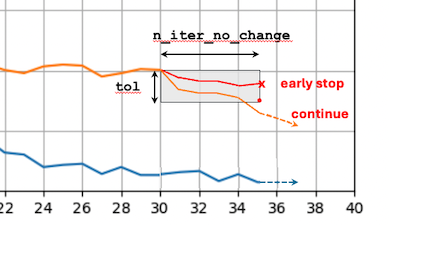

This helps prevent unnecessary model complexity and reduces overfitting while also making training more efficient. This is a useful technique for boosting models and deep learning models, since they tend to have performance plateaus rather than distinct minima.  

Default HistGradientBoostingClassifier
--------------------------------------
Mean CV ROC AUC : 0.9794
CV AUC Std      : 0.0033

Out-of-Fold Metrics at Threshold = 0.5
---------------------------------------
Accuracy        : 0.9253
F1 Score        : 0.8957
TPR / Recall    : 0.8588
FPR             : 0.0351


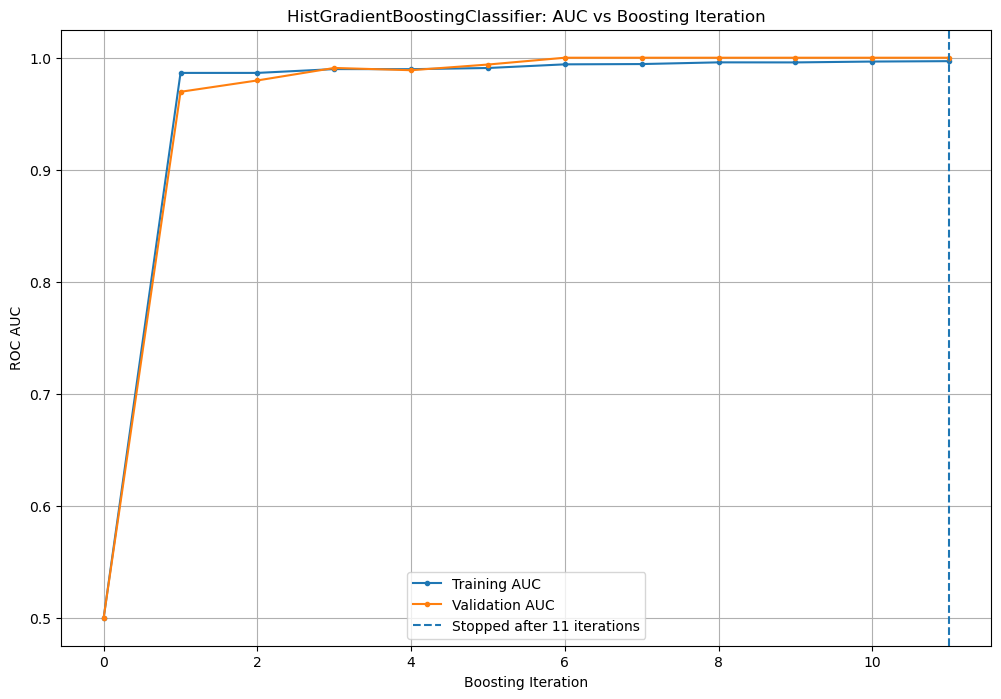

Number of boosting iterations used: 11


In [11]:
# -------------------------------------------------------------
# Default HistGradientBoostingClassifier
# -------------------------------------------------------------


# --------------------------------------------------
# Initialize the classifier
# --------------------------------------------------

model_HGBC_default = HistGradientBoostingClassifier(

    # Tree structure and learning rate
    learning_rate       = 0.1,          # Default
    max_leaf_nodes      = 31,
    max_depth           = None,
    min_samples_leaf    = 20,
    l2_regularization   = 0.0,

    # Binning and boosting
    max_bins            = 255,
    max_iter            = 1000,

    # Early stopping / validation tracking
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 5,
    tol                 = 1e-7,

    # Use ROC AUC for early stopping
    scoring             = "roc_auc",

    # Reproducibility
    random_state        = random_seed
)


# --------------------------------------------------
# Fit on the full development set
# Used here to examine early stopping behavior
# --------------------------------------------------

model_HGBC_default.fit(X2_dev, y2_dev)


# --------------------------------------------------
# Stratified 5-Fold Cross-Validation
# --------------------------------------------------

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)


# --------------------------------------------------
# Primary metric: ROC AUC
# --------------------------------------------------

cv_auc = cross_val_score(
    model_HGBC_default,
    X2_dev,
    y2_dev,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1
)

mean_cv_auc = cv_auc.mean()
std_cv_auc = cv_auc.std()


# --------------------------------------------------
# Out-of-fold probabilities and predictions
# --------------------------------------------------

oof_prob = cross_val_predict(
    model_HGBC_default,
    X2_dev,
    y2_dev,
    cv=cv5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Default classification threshold
oof_pred = (oof_prob >= 0.5).astype(int)


# --------------------------------------------------
# Threshold-dependent metrics
# --------------------------------------------------

accuracy = accuracy_score(y2_dev, oof_pred)
f1 = f1_score(y2_dev, oof_pred)

tn, fp, fn, tp = confusion_matrix(
    y2_dev,
    oof_pred,
    labels=[0, 1]
).ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)


# --------------------------------------------------
# Report CV performance
# --------------------------------------------------

print("Default HistGradientBoostingClassifier")
print("--------------------------------------")

print(f"Mean CV ROC AUC : {mean_cv_auc:.4f}")
print(f"CV AUC Std      : {std_cv_auc:.4f}")
print()

print("Out-of-Fold Metrics at Threshold = 0.5")
print("---------------------------------------")
print(f"Accuracy        : {accuracy:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"TPR / Recall    : {tpr:.4f}")
print(f"FPR             : {fpr:.4f}")


# --------------------------------------------------
# Extract internal training and validation AUC
# --------------------------------------------------

iterations = range(
    len(model_HGBC_default.train_score_)
)

training_auc = model_HGBC_default.train_score_
validation_auc = model_HGBC_default.validation_score_


# --------------------------------------------------
# Plot AUC vs boosting iteration
# --------------------------------------------------

plt.figure(figsize=(12, 8))

plt.plot(
    iterations,
    training_auc,
    marker=".",
    label="Training AUC"
)

plt.plot(
    iterations,
    validation_auc,
    marker=".",
    label="Validation AUC"
)

plt.axvline(
    model_HGBC_default.n_iter_,
    linestyle="--",
    label=(
        f"Stopped after "
        f"{model_HGBC_default.n_iter_} iterations"
    )
)

plt.title(
    "HistGradientBoostingClassifier: "
    "AUC vs Boosting Iteration"
)

plt.xlabel("Boosting Iteration")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid()

plt.show()

print(
    f"Number of boosting iterations used: "
    f"{model_HGBC_default.n_iter_}"
)

### Hyperparameter Tuning Wrapper Function

In [12]:
# --------------------------------------------------
# Stratified 5-Fold Cross-Validation
# Used for exploratory parameter sweeps
# --------------------------------------------------

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)


def sweep_hist_gradient_boosting_classifier(
    param,
    parameter_list,
    early_stop=True
):

    training_aucs = []
    cv_aucs = []

    # Large ceiling when early stopping is active
    limit = 1000 if early_stop else 100

    for value in tqdm(parameter_list):

        model_params = {

            # Tree structure and learning rate
            "learning_rate": 0.1,
            "max_leaf_nodes": 31,
            "max_depth": None,
            "min_samples_leaf": 20,
            "l2_regularization": 0.0,
            "max_features": 1.0,

            # Binning and boosting
            "max_bins": 255,
            "max_iter": limit,

            # Early stopping
            "early_stopping": early_stop,
            "validation_fraction": 0.1,
            "n_iter_no_change": 5,
            "tol": 1e-7,

            # Use ROC AUC for early stopping
            "scoring": "roc_auc",

            # Reproducibility
            "random_state": random_seed
        }

        # --------------------------------------------------
        # Change only the parameter being studied
        # --------------------------------------------------

        model_params[param] = value

        model = HistGradientBoostingClassifier(
            **model_params
        )

        # --------------------------------------------------
        # Stratified 5-Fold Cross-Validation
        # --------------------------------------------------

        scores = cross_validate(
            model,
            X2_dev,
            y2_dev,
            scoring="roc_auc",
            cv=cv5,
            n_jobs=-1,
            return_train_score=True
        )

        training_aucs.append(
            scores["train_score"].mean()
        )

        cv_aucs.append(
            scores["test_score"].mean()
        )


    # --------------------------------------------------
    # Identify best CV ROC AUC
    # --------------------------------------------------

    best_index = np.argmax(cv_aucs)

    best_value = parameter_list[best_index]
    best_cv_auc = cv_aucs[best_index]


    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    plt.figure(figsize=(7, 5))

    plt.plot(
        parameter_list,
        training_aucs,
        marker=".",
        label="Training AUC"
    )

    plt.plot(
        parameter_list,
        cv_aucs,
        marker=".",
        label="CV AUC"
    )

    plt.scatter(
        best_value,
        best_cv_auc,
        marker="x",
        s=80,
        label=(
            f"Best CV AUC = {best_cv_auc:.4f}\n"
            f"at {param} = {best_value}"
        )
    )

    plt.title(
        f"HistGradientBoostingClassifier: "
        f"AUC vs {param}"
    )

    plt.xlabel(param)
    plt.ylabel("ROC AUC")

    plt.legend()
    plt.grid()

    plt.show()


    # --------------------------------------------------
    # Report result
    # --------------------------------------------------

    print(
        f"Maximum CV AUC = {best_cv_auc:.4f}"
    )

    print(
        f"Best {param} = {best_value}"
    )

### Hyperparameter Tuning

Most useful hyperparameters to sweep:

- `learning_rate`
- `max_leaf_nodes`
- `min_samples_leaf`

100%|███████████████████████████████████████████| 71/71 [00:03<00:00, 17.97it/s]


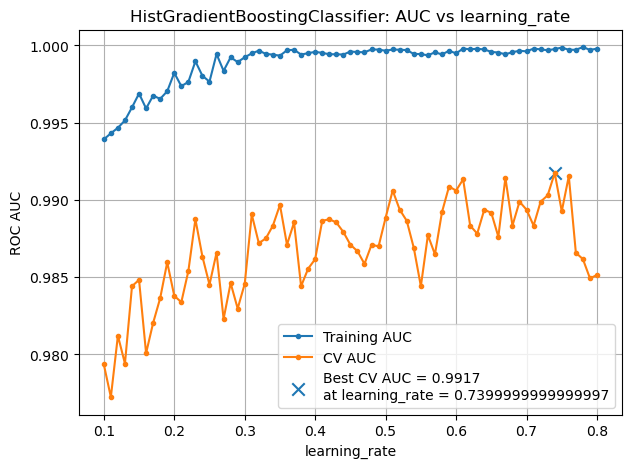

Maximum CV AUC = 0.9917
Best learning_rate = 0.7399999999999997


In [13]:
param = "learning_rate"
parameter_list = np.arange(0.1, 0.81, 0.01)

sweep_hist_gradient_boosting_classifier(
    param,
    parameter_list
)

100%|███████████████████████████████████████████| 19/19 [00:00<00:00, 22.18it/s]


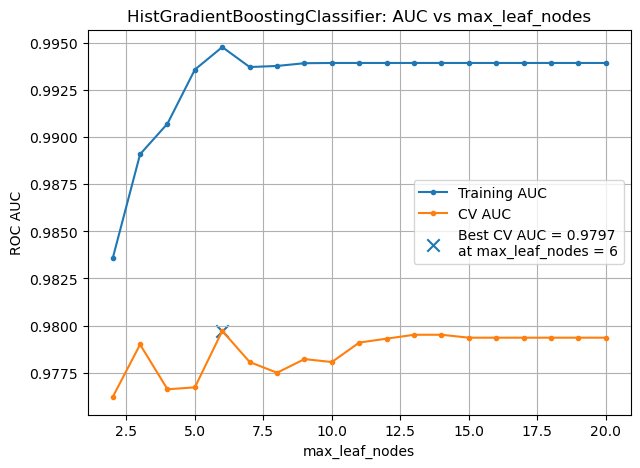

Maximum CV AUC = 0.9797
Best max_leaf_nodes = 6


In [14]:
param = "max_leaf_nodes"
parameter_list = range(2, 21)

sweep_hist_gradient_boosting_classifier(
    param,
    parameter_list
)

100%|███████████████████████████████████████████| 21/21 [00:01<00:00, 17.27it/s]


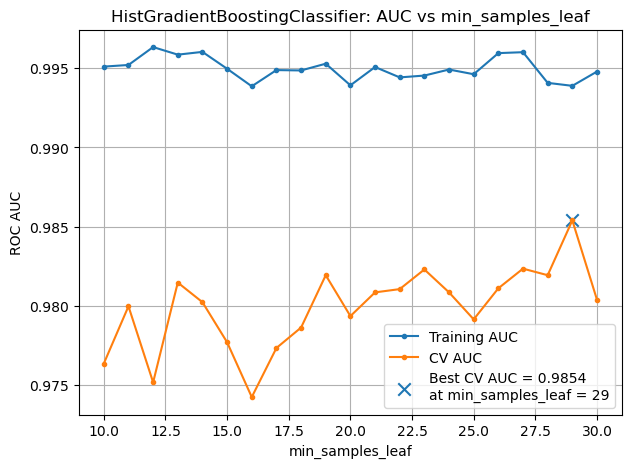

Maximum CV AUC = 0.9854
Best min_samples_leaf = 29


In [15]:
param = "min_samples_leaf"
parameter_list = range(10, 31)

sweep_hist_gradient_boosting_classifier(
    param,
    parameter_list
)

#### Comment:

The individual sweeps reveal several useful patterns. 
- For `learning_rate`, performance improves substantially from the lower values and then enters a broad high-performing region, with the best result occurring near the upper end of the range.
- For `max_leaf_nodes`, performance improves quickly as the trees become more complex, but then largely plateaus once the number of leaves is moderate.
- The `min_samples_leaf` sweep is noisier, although the strongest results occur in the middle-to-upper part of the range rather than at the extremes.

> These sweeps help us understand how each hyperparameter behaves in isolation and identify promising regions, but they do not account for interactions among hyperparameters. We therefore now use `GridSearchCV` over restricted ranges of `learning_rate`, `max_leaf_nodes`, and `min_samples_leaf`, together with repeated stratified cross-validation and ROC AUC as the selection metric. This allows us to evaluate combinations of hyperparameter values more systematically and make the final model selection using development-set evidence only.

### Grid Search over Plateaus

In [16]:

start = time.perf_counter()

# ------------------------------------------------------------
# Parameter grid
# Replace these ranges after reviewing the manual sweeps
# ------------------------------------------------------------

param_grid = {

    # Learning rate
    "learning_rate": np.arange(0.55, 0.75, 0.01),

    # Maximum number of leaves in each tree
    "max_leaf_nodes": range(2, 11),

    # Minimum number of observations in each leaf
    "min_samples_leaf": range(12,21)
}


# ------------------------------------------------------------
# Initialize classifier
# ------------------------------------------------------------

model_HGBC_GS = HistGradientBoostingClassifier(

    # Tree structure
    max_depth=None,
    l2_regularization=0.0,

    # Binning
    max_bins=255,

    # Maximum boosting iterations
    # Early stopping will usually stop before this limit
    max_iter=1000,

    # Early stopping
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    tol=1e-7,

    # Use ROC AUC for early stopping
    scoring="roc_auc",

    # Reproducibility
    random_state=random_seed
)


# ------------------------------------------------------------
# Repeated Stratified Cross-Validation
# ------------------------------------------------------------

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_seed
)


# ------------------------------------------------------------
# Grid Search
# ------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=model_HGBC_GS,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X2_dev,
    y2_dev
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

results = pd.DataFrame(
    grid_search.cv_results_
)

columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_learning_rate",
    "param_max_leaf_nodes",
    "param_min_samples_leaf"
]

results = (
    results[columns]
    .sort_values("rank_test_score")
    .rename(columns={
        "rank_test_score": "Rank",
        "mean_test_score": "CV AUC",
        "std_test_score": "CV Std",
        "mean_train_score": "Training AUC",
        "param_learning_rate": "learning_rate",
        "param_max_leaf_nodes": "max_leaf_nodes",
        "param_min_samples_leaf": "min_samples_leaf"
    })
)

print(f"Best CV AUC = {grid_search.best_score_:.4f}")
print(f"Best Parameters = {grid_search.best_params_}")

display(
    results
    .head(20)
    .round(4)
)

print_elapsed_time(start)

/opt/homebrew/Caskroom/miniforge/base/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV AUC = 0.9918
Best Parameters = {'learning_rate': 0.7300000000000002, 'max_leaf_nodes': 10, 'min_samples_leaf': 17}


,Rank,CV AUC,CV Std,Training AUC,learning_rate,max_leaf_nodes,min_samples_leaf
1535,1,0.9918,0.0062,0.9997,0.73,10,17
1007,2,0.9917,0.0062,0.9997,0.67,5,20
926,3,0.9913,0.0070,0.9997,0.66,5,20
771,4,0.9912,0.0065,0.9997,0.64,6,18
1357,5,0.9912,0.0072,0.9996,0.71,8,19
1526,6,0.9911,0.0065,0.9998,0.73,9,17
1454,7,0.9911,0.0081,0.9997,0.72,10,17
1186,8,0.9911,0.0073,0.9996,0.69,7,19
1412,9,0.9911,0.0078,0.9997,0.72,5,20
1527,10,0.9910,0.0081,0.9997,0.73,9,18


Elapsed time = 00:01:00


#### Comment:

The grid search identifies a best mean cross-validation ROC AUC of approximately 0.992, but many nearby hyperparameter combinations achieve nearly identical performance. The differences among the highest-ranked models are small relative to the variation across cross-validation folds, so the results are better interpreted as identifying a **broad region of strong performance** rather than one uniquely optimal model.

The top-ranked model uses `learning_rate = 0.73`, `max_leaf_nodes = 10`, and `min_samples_leaf = 17`. Although some of these values lie near the edge of the search range, the other top models span a range of learning rates and tree complexities with nearly indistinguishable CV AUC. Together with the plateaus observed in the individual sweeps, this gives little reason to expand the search simply to pursue a slightly better numerical optimum.

Because GridSearchCV evaluates these hyperparameters jointly using repeated stratified cross-validation, it accounts for interactions among them and provides our final basis for model selection. We therefore select the top-ranked model, refit it on the full development set, and evaluate it once on the untouched test set.

### Final Exam!

Final HistGradientBoosting Classification Test Results
-------------------------------------------------
Best CV ROC AUC : 0.9918
Test ROC AUC    : 0.9917

Test Metrics at Threshold = 0.5
--------------------------------
Accuracy        : 0.9825
Precision       : 1.0000
TPR / Recall    : 0.9524
FPR             : 0.0000
F1 Score        : 0.9756


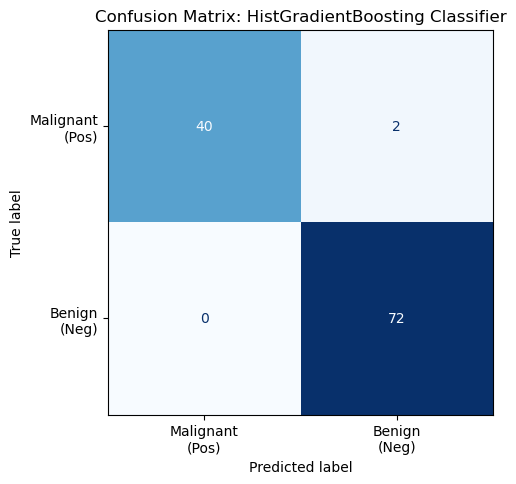

In [17]:
# --------------------------------------------------
# Final HistGradientBoosting Model
# --------------------------------------------------

model_HGBC_final = grid_search.best_estimator_

# Refit selected model on the full development set
model_HGBC_final.fit(
    X2_dev,
    y2_dev
)


# --------------------------------------------------
# Evaluate once on the untouched test set
# --------------------------------------------------

# Predicted probabilities for the positive class
# 1 = Malignant
y2_prob = model_HGBC_final.predict_proba(
    X2_test
)[:, 1]

# Class predictions using the default threshold = 0.5
y2_pred = model_HGBC_final.predict(
    X2_test
)


# --------------------------------------------------
# Classification metrics
# --------------------------------------------------

auc = roc_auc_score(
    y2_test,
    y2_prob
)

accuracy = accuracy_score(
    y2_test,
    y2_pred
)

precision = precision_score(
    y2_test,
    y2_pred
)

tpr = recall_score(
    y2_test,
    y2_pred
)

f1 = f1_score(
    y2_test,
    y2_pred
)


# --------------------------------------------------
# Confusion matrix
# --------------------------------------------------

# Arrange classes as:
#     1 = Malignant (Positive)
#     0 = Benign (Negative)

cm = confusion_matrix(
    y2_test,
    y2_pred,
    labels=[1, 0]
)

# With labels=[1, 0]:
# [[TP, FN],
#  [FP, TN]]

tp, fn, fp, tn = cm.ravel()

fpr = fp / (fp + tn)


# --------------------------------------------------
# Report results
# --------------------------------------------------

print("Final HistGradientBoosting Classification Test Results")
print("-------------------------------------------------")

print(f"Best CV ROC AUC : {grid_search.best_score_:.4f}")
print(f"Test ROC AUC    : {auc:.4f}")
print()

print("Test Metrics at Threshold = 0.5")
print("--------------------------------")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"TPR / Recall    : {tpr:.4f}")
print(f"FPR             : {fpr:.4f}")
print(f"F1 Score        : {f1:.4f}")


# --------------------------------------------------
# Plot confusion matrix
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Malignant\n(Pos)",
        "Benign\n(Neg)"
    ]
).plot(
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Confusion Matrix: HistGradientBoosting Classifier"
)

plt.show()

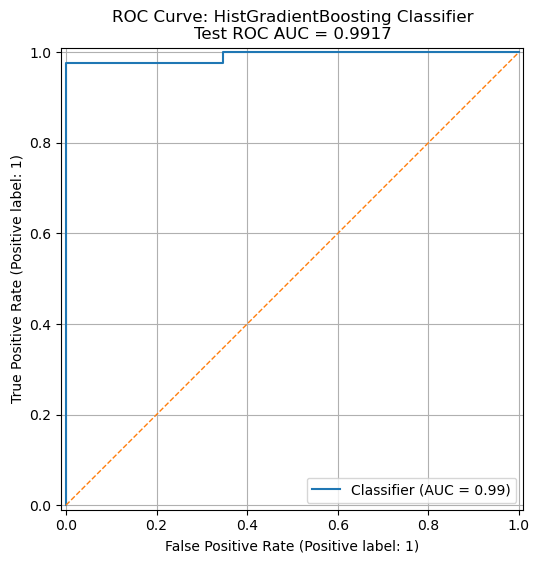

In [18]:
# --------------------------------------------------
# ROC Curve on the Test Set
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_predictions(
    y2_test,
    y2_prob,
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

ax.set_title(
    f"ROC Curve: HistGradientBoosting Classifier\n"
    f"Test ROC AUC = {auc:.4f}"
)

ax.grid()

plt.show()

## Feature Importance

We'll demonstrate impurity-based feature importance for the regression model, and permutation importance for the classification model. 

,Feature,Importance
0,MedInc,0.394466
6,Latitude,0.129510
7,Longitude,0.126614
5,AveOccup,0.125469
2,AveRooms,0.102660
1,HouseAge,0.051961
3,AveBedrms,0.039251
4,Population,0.030068


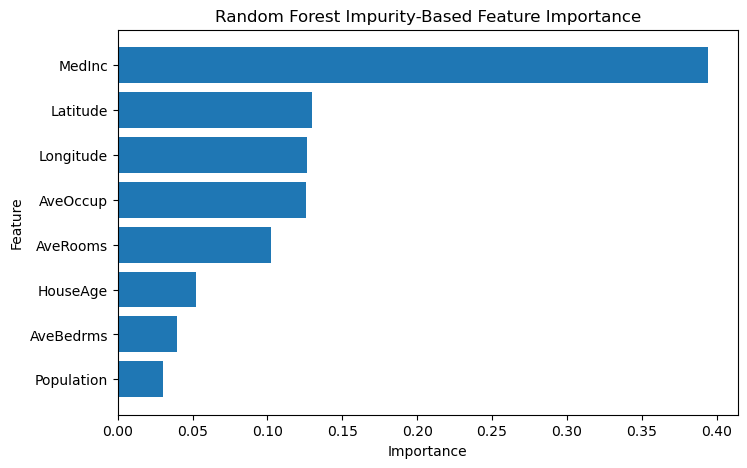

In [19]:
# ------------------------------------------------------------
# Random Forest Impurity-Based Feature Importance: CA Housing
# ------------------------------------------------------------

# Extract the fitted RandomForestRegressor from the pipeline
rf_model = model_RFR_final.named_steps[
    "randomforestregressor"
]


# ------------------------------------------------------------
# Impurity-based feature importance
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df)


# ------------------------------------------------------------
# Plot feature importance
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest Impurity-Based Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

,Feature,Importance,Std
27,worst concave points,0.0038,0.0012
21,worst texture,0.0013,0.0006
7,mean concave points,0.0012,0.0006
1,mean texture,0.0007,0.0005
20,worst radius,0.0003,0.0003
23,worst area,0.0002,0.0002
4,mean smoothness,0.0000,0.0000
22,worst perimeter,0.0000,0.0000
15,compactness error,0.0000,0.0000
29,worst fractal dimension,0.0000,0.0000


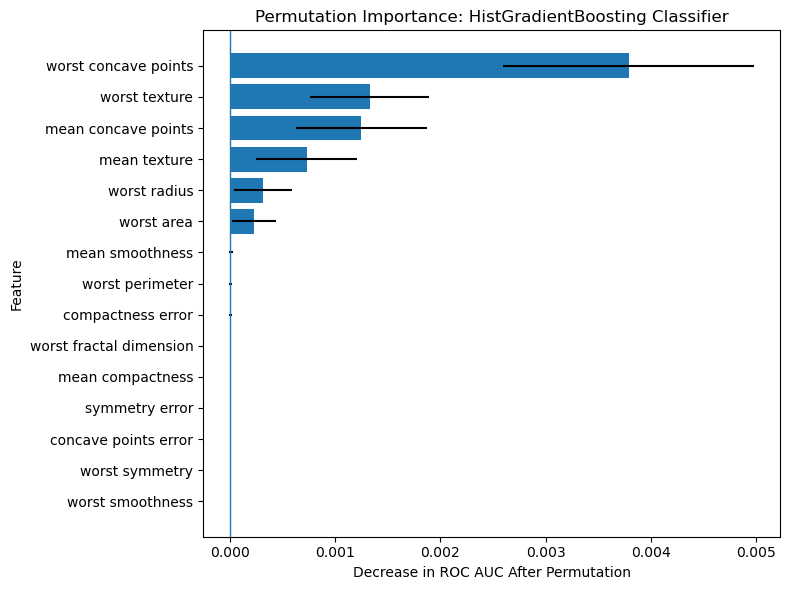

In [20]:
# ------------------------------------------------------------
# Permutation Importance: HistGradientBoosting Classifier
# Wisconsin Breast Cancer Dataset
# ------------------------------------------------------------

# ------------------------------------------------------------
# Feature names
# ------------------------------------------------------------

if isinstance(X2_dev, pd.DataFrame):
    feature_names = X2_dev.columns
else:
    feature_names = cancer.feature_names


# ------------------------------------------------------------
# Permutation importance on the development set
# Primary metric: ROC AUC
# ------------------------------------------------------------

perm_result = permutation_importance(
    model_HGBC_final,
    X2_dev,
    y2_dev,
    scoring="roc_auc",
    n_repeats=30,
    random_state=random_seed,
    n_jobs=-1
)


# ------------------------------------------------------------
# Organize results
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df
    .head(15)
    .round(4)
)


# ------------------------------------------------------------
# Plot the 15 most important features
# ------------------------------------------------------------

top_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    xerr=top_features["Std"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Permutation Importance: HistGradientBoosting Classifier"
)

plt.xlabel(
    "Decrease in ROC AUC After Permutation"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Conclusions

- **Ensemble methods can substantially improve on individual decision trees** by combining many trees rather than relying on a single fitted structure.

- **Manual hyperparameter sweeps are useful for understanding model behavior.** They show how individual parameters affect training and cross-validation performance and help identify promising regions for further search.

- **One-parameter-at-a-time sweeps cannot capture interactions among hyperparameters.** We therefore used `RandomizedSearchCV` for the higher-dimensional Random Forest search and `GridSearchCV` for the more restricted boosting search.

- **Repeated cross-validation provides a more stable basis for final model selection.** We used repeated K-fold CV for regression and repeated stratified K-fold CV for classification.

- For the **Random Forest Regressor**, MAE was used throughout model selection. The best randomized-search model achieved a development-set CV MAE of about **0.325** and a test MAE of about **0.317**. 

- For the **HistGradientBoostingClassifier**, ROC AUC was the primary selection metric. Early stopping controlled the number of boosting iterations, while the remaining hyperparameters were tuned using repeated stratified cross-validation. :contentReference[oaicite:1]{index=1}

- The selected boosting model achieved a repeated-CV ROC AUC of about **0.992** and a test ROC AUC of about **0.992**. At the default threshold of 0.5, it also achieved high accuracy and TPR with an FPR of 0 on this test sample.

- **The test set was kept untouched during model selection** and used only once after the final model had been chosen and refit on the full development set.

- Finally, **feature importance provides a way to interpret ensemble models**: Random Forests offer impurity-based importance directly, while permutation importance can be used more generally to measure how much predictive performance decreases when a feature is disrupted. 